# 📊 Exploratory Data Analysis — Student Placement Dataset

This notebook performs a full EDA and feature engineering pipeline on the cleaned placement dataset containing **40,307 student records** across **10 features**. The target variable `Placement` indicates placement outcome (multi-class: 0–4).

---
## Table of Contents
1. [Library Imports & Setup](#1)
2. [Data Loading & Overview](#2)
3. [Missing Values & Data Quality](#3)
4. [Univariate Analysis](#4)
5. [Bivariate Analysis](#5)
6. [Correlation Analysis](#6)
7. [Target Variable Analysis](#7)
8. [Feature Engineering](#8)
9. [Outlier Detection](#9)
10. [Summary & Key Insights](#10)

---
## 1. Library Imports & Setup <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False
})

SEED = 42
np.random.seed(SEED)

---
## 2. Data Loading & Overview <a id='2'></a>

In [2]:
df = pd.read_csv('cleaned_placement_data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (40307, 10)


,IQ,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,branch_encoded,KT,CGPA_Final,Placement
0,100,5.814012,1,6.154023,4.842362,2,4,2,6.653333,1
1,120,3.712947,0,3.593549,2.000000,3,1,3,1.660000,1
2,117,3.000000,1,6.000000,7.000000,0,3,6,6.635000,1
3,127,5.000000,1,4.000000,3.057480,2,0,3,6.860000,0
4,102,8.000000,1,1.000000,5.335326,2,2,3,5.570000,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40307 entries, 0 to 40306
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IQ                      40307 non-null  int64  
 1   Academic_Performance    40307 non-null  float64
 2   Internship_Experience   40307 non-null  int64  
 3   Extra_Curricular_Score  40307 non-null  float64
 4   Communication_Skills    40307 non-null  float64
 5   Projects_Completed      40307 non-null  int64  
 6   branch_encoded          40307 non-null  int64  
 7   KT                      40307 non-null  int64  
 8   CGPA_Final              40307 non-null  float64
 9   Placement               40307 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 3.1 MB


In [4]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std']).format(precision=3)

,count,mean,std,min,25%,50%,75%,max
IQ,40307.000,100.912,11.933,50.000,95.000,101.000,106.000,200.000
Academic_Performance,40307.000,5.281,2.312,0.000,3.977,5.193,6.816,10.000
Internship_Experience,40307.000,0.404,0.491,0.000,0.000,0.000,1.000,1.000
Extra_Curricular_Score,40307.000,4.896,2.388,0.000,3.678,4.860,6.000,10.000
Communication_Skills,40307.000,5.379,2.356,0.000,4.000,5.277,7.000,10.000
Projects_Completed,40307.000,2.553,1.443,0.000,2.000,3.000,3.000,12.000
branch_encoded,40307.000,1.664,0.970,0.000,1.000,1.000,2.000,4.000
KT,40307.000,2.680,1.590,0.000,2.000,3.000,3.000,18.000
CGPA_Final,40307.000,6.794,1.581,0.000,5.916,6.850,7.810,10.000
Placement,40307.000,0.313,0.465,0.000,0.000,0.000,1.000,4.000


**Key Observations:**
- Dataset has **40,307 rows** and **10 columns** — all numeric, no nulls.
- `Placement` is the target with values **0–4** (multi-class ordinal).
- `IQ` ranges from 50–200, `CGPA_Final` from 0–10, `KT` (backlogs) from 0–18.
- `Internship_Experience` and `branch_encoded` are binary/categorical encoded as integers.

---
## 3. Missing Values & Data Quality <a id='3'></a>

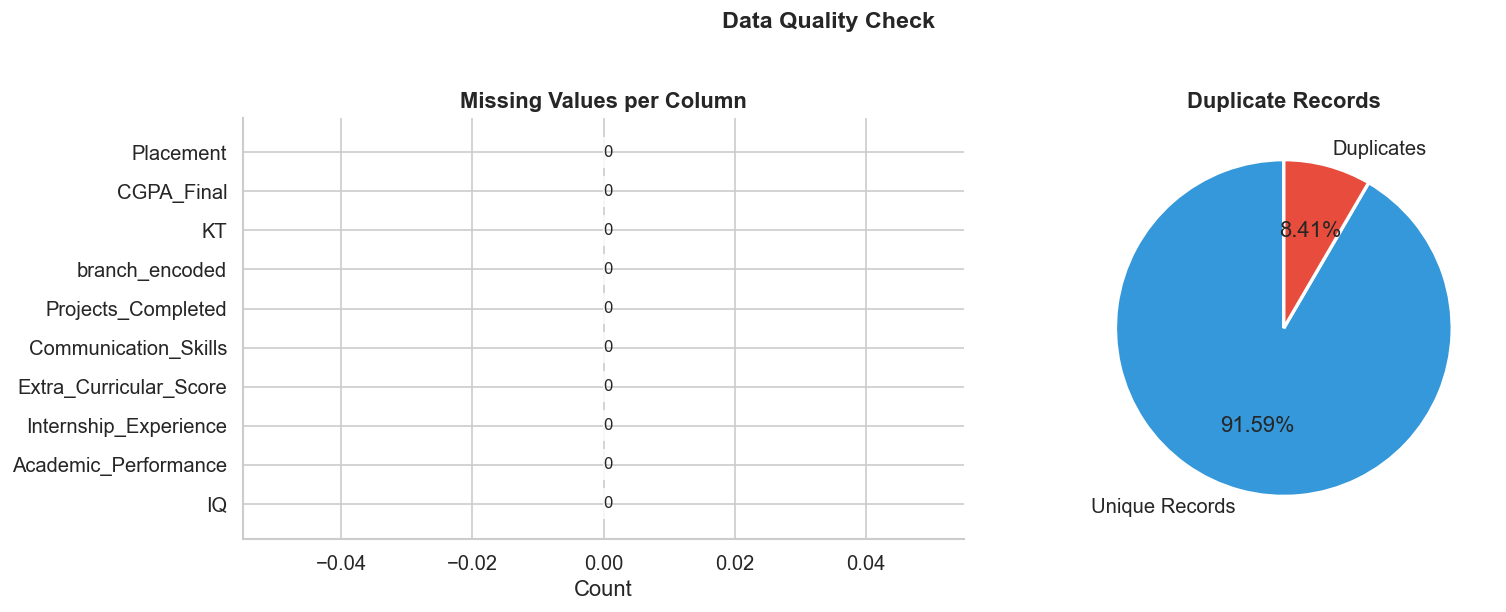

Total Missing: 0 | Duplicates: 3390


In [5]:
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if v == 0 else '#e74c3c' for v in missing.values]
axes[0].barh(missing.index, missing.values, color=colors)
axes[0].set_title('Missing Values per Column', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(missing.values):
    axes[0].text(max(missing.values) * 0.01, i, f'{v}', va='center', fontsize=10)

labels = ['Unique Records', 'Duplicates']
sizes = [len(df) - duplicates, duplicates]
axes[1].pie(sizes, labels=labels, autopct='%1.2f%%',
            colors=['#3498db', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Duplicate Records', fontweight='bold')

plt.suptitle('Data Quality Check', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"Total Missing: {missing.sum()} | Duplicates: {duplicates}")

---
## 4. Univariate Analysis <a id='4'></a>

### 4.1 Distribution of Continuous Features

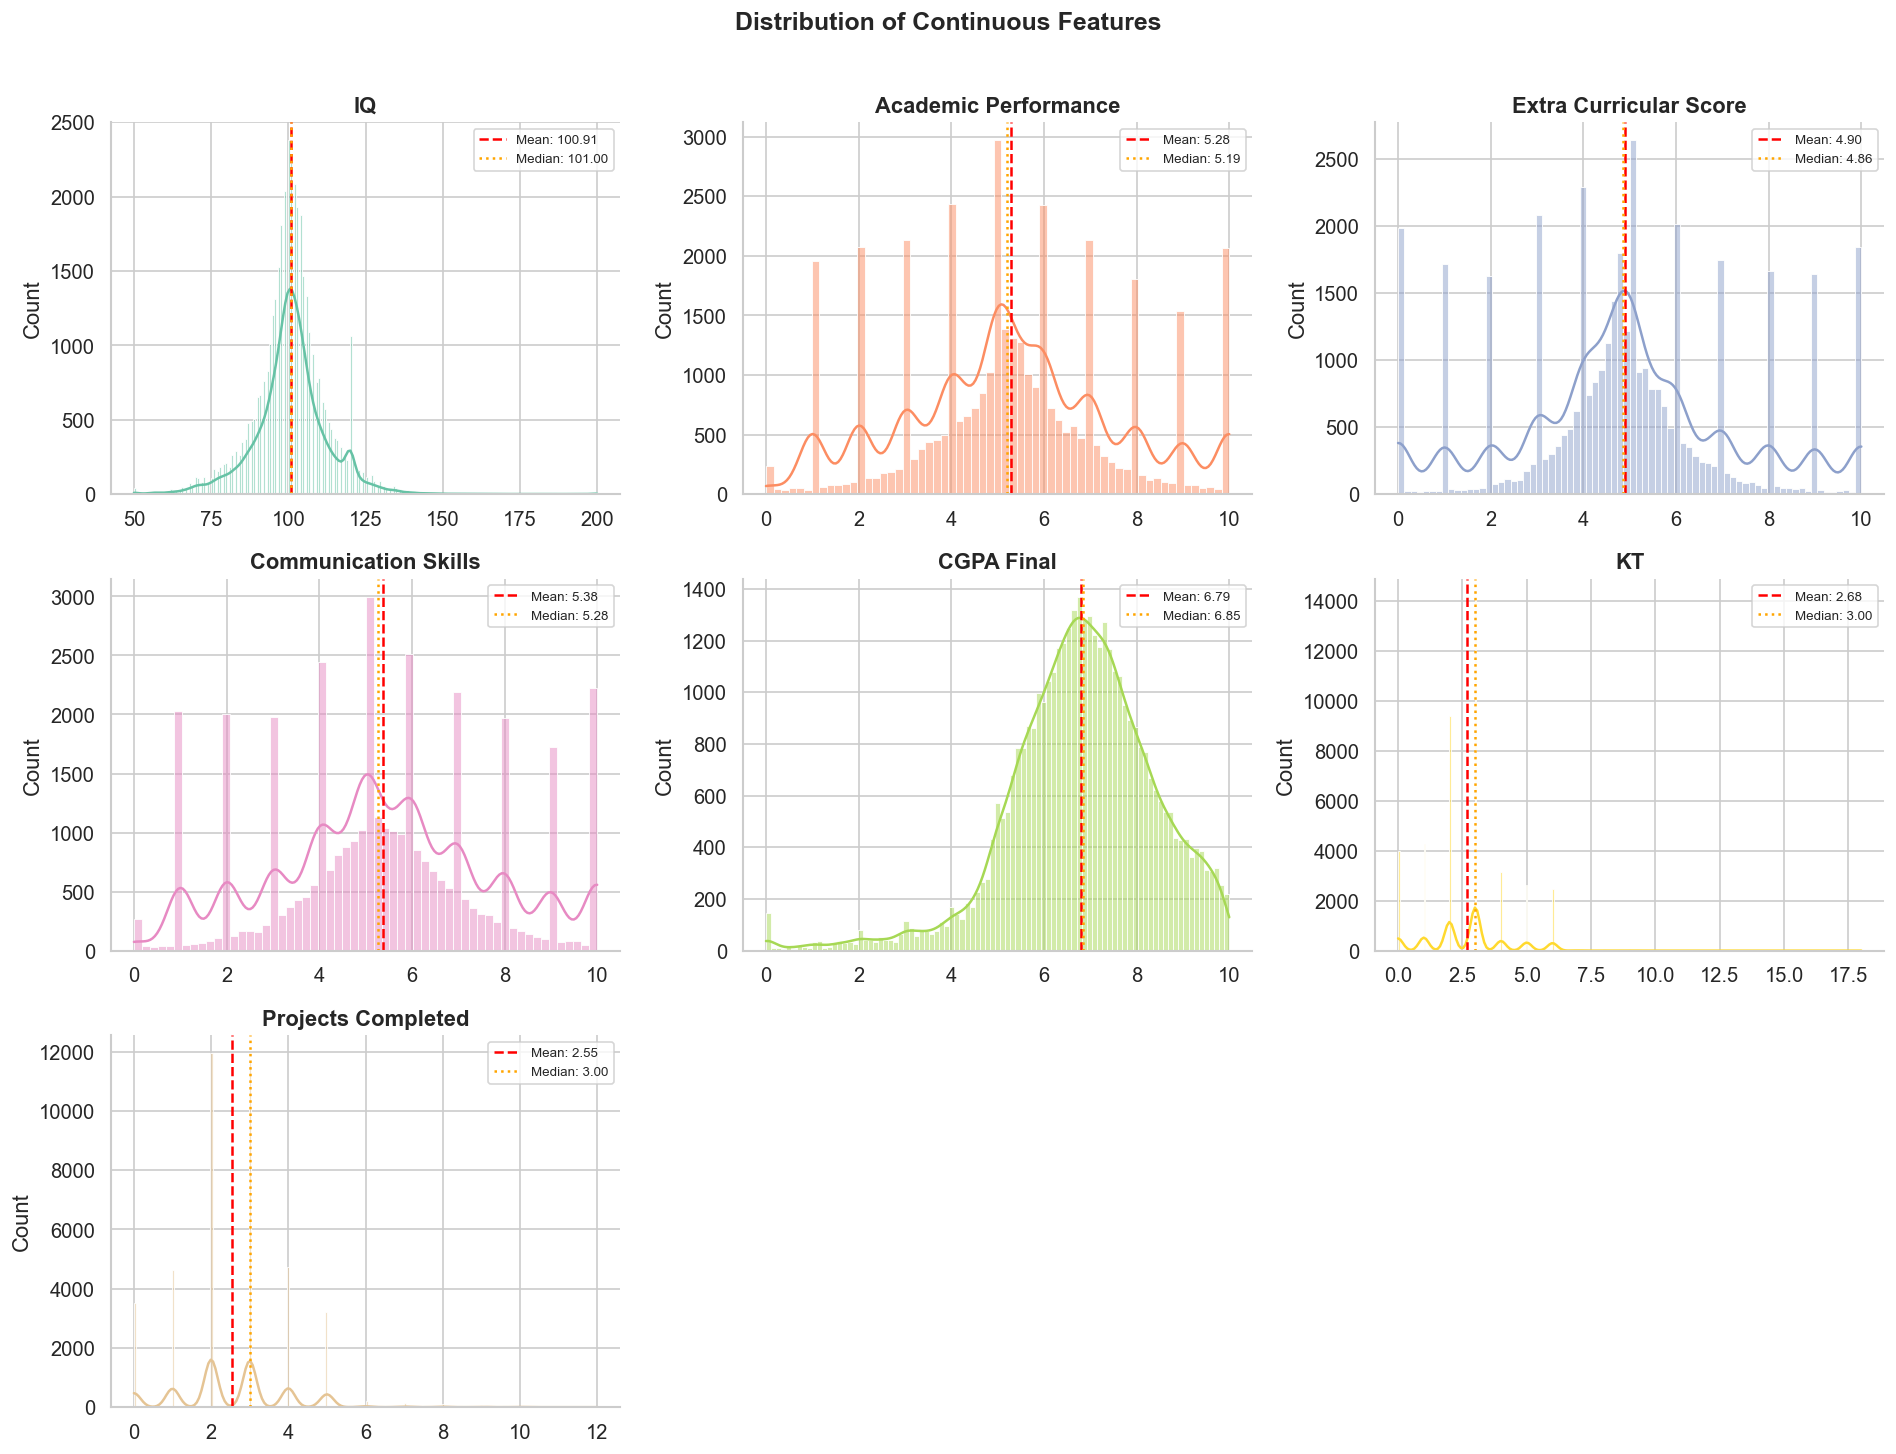

In [6]:
continuous_cols = ['IQ', 'Academic_Performance', 'Extra_Curricular_Score',
                   'Communication_Skills', 'CGPA_Final', 'KT', 'Projects_Completed']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

palette = sns.color_palette('Set2', len(continuous_cols))

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color=palette[i], edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle=':', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    ax.set_title(col.replace('_', ' '), fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

for j in range(len(continuous_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Continuous Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Categorical Features

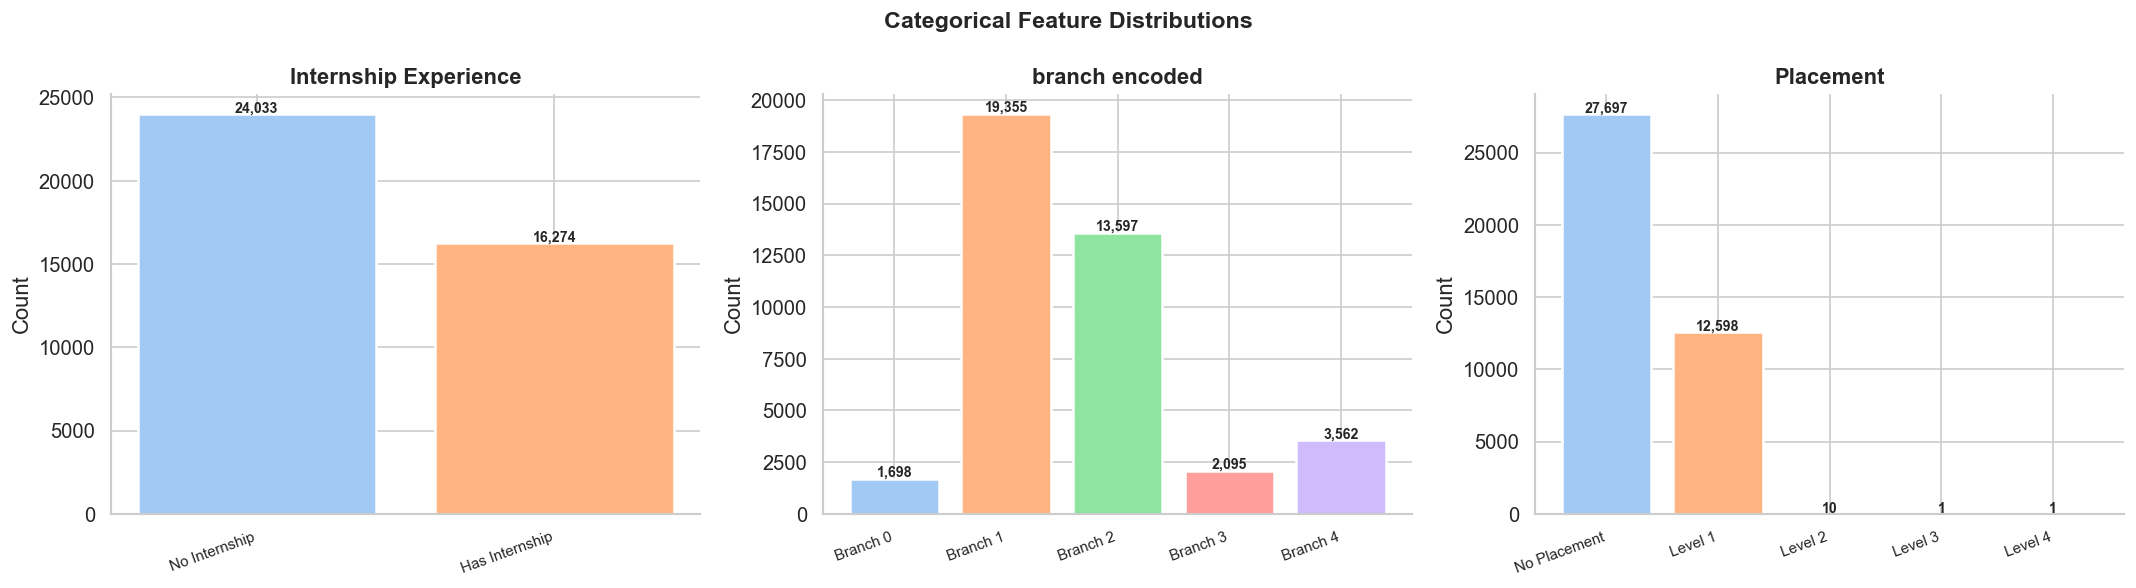

In [7]:
cat_cols = ['Internship_Experience', 'branch_encoded', 'Placement']
cat_labels = {
    'Internship_Experience': ['No Internship', 'Has Internship'],
    'branch_encoded': ['Branch 0', 'Branch 1', 'Branch 2', 'Branch 3', 'Branch 4'],
    'Placement': ['No Placement', 'Level 1', 'Level 2', 'Level 3', 'Level 4']
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts().sort_index()
    bars = axes[i].bar(range(len(vc)), vc.values,
                       color=sns.color_palette('pastel', len(vc)),
                       edgecolor='white', linewidth=1.5)
    axes[i].set_xticks(range(len(vc)))
    axes[i].set_xticklabels(cat_labels[col], rotation=20, ha='right', fontsize=9)
    axes[i].set_title(col.replace('_', ' '), fontweight='bold')
    axes[i].set_ylabel('Count')
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + 100,
                     f'{int(h):,}', ha='center', fontsize=8.5, fontweight='bold')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Bivariate Analysis <a id='5'></a>

### 5.1 Feature vs Placement (Box Plots)

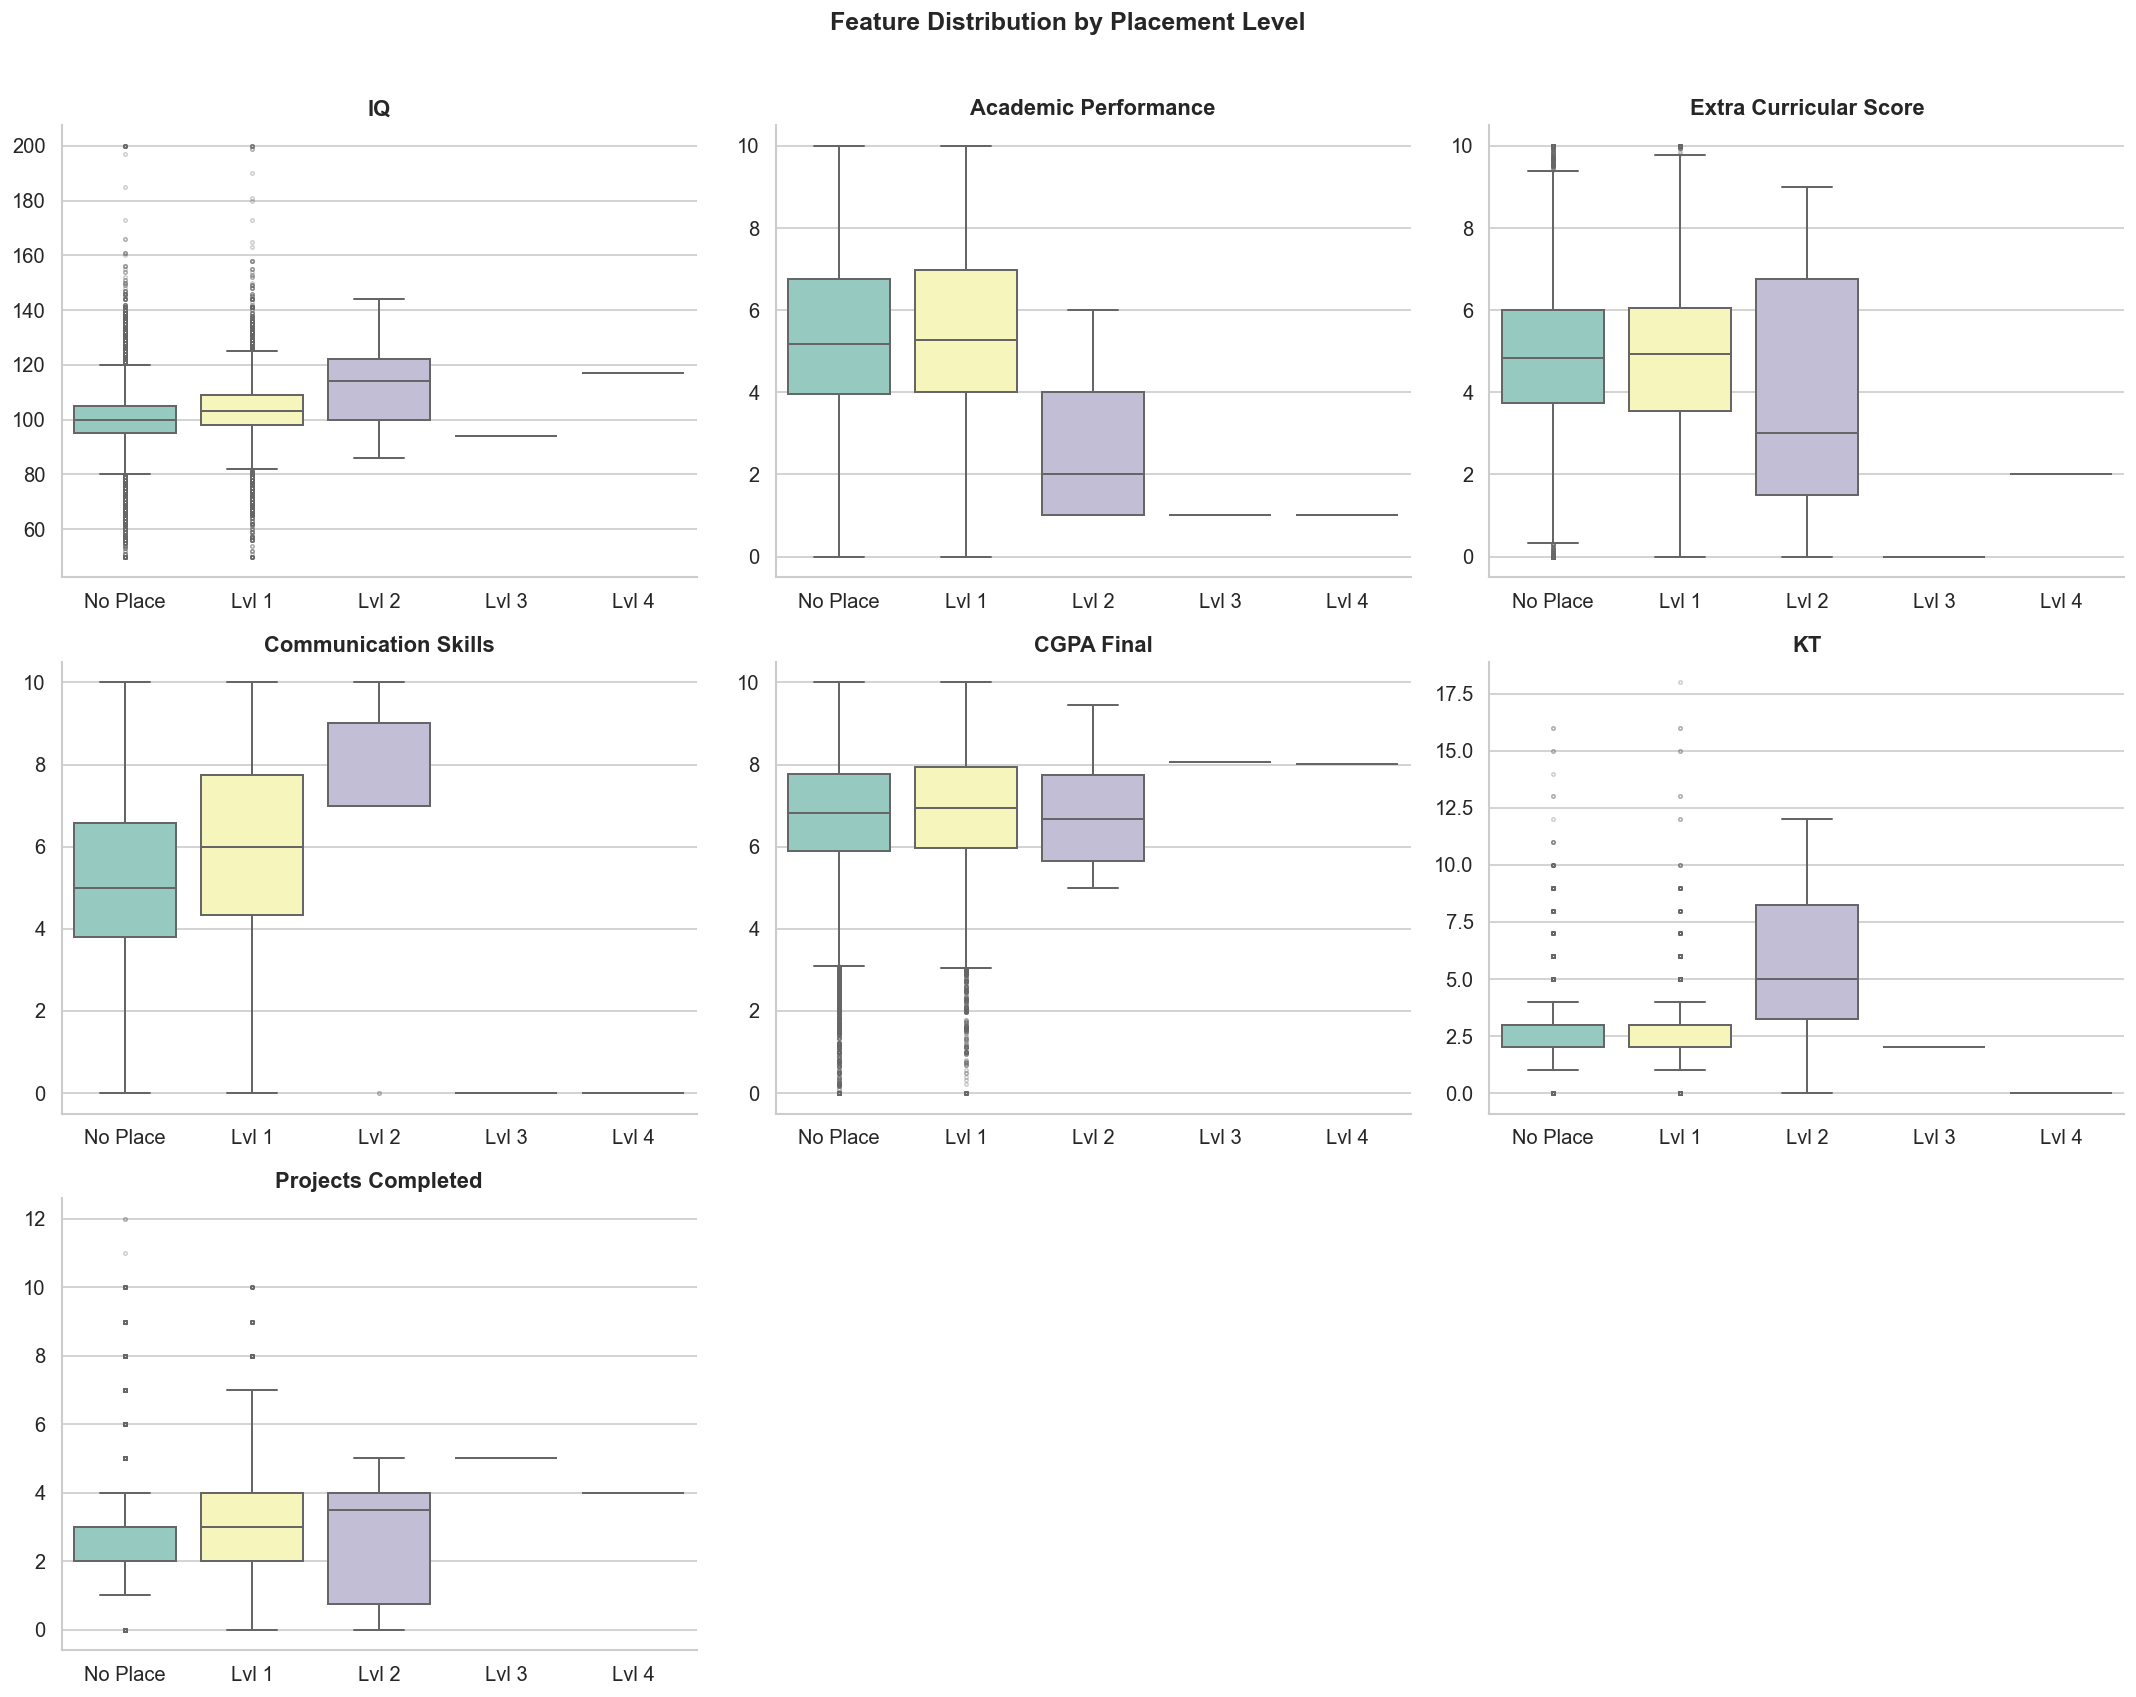

In [8]:
placement_labels = {0: 'No Place', 1: 'Lvl 1', 2: 'Lvl 2', 3: 'Lvl 3', 4: 'Lvl 4'}
df['Placement_Label'] = df['Placement'].map(placement_labels)
order = ['No Place', 'Lvl 1', 'Lvl 2', 'Lvl 3', 'Lvl 4']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df, x='Placement_Label', y=col, order=order,
                ax=axes[i], palette='Set3', linewidth=1.2,
                flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
    axes[i].set_title(col.replace('_', ' '), fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(continuous_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distribution by Placement Level', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Internship Experience vs Placement

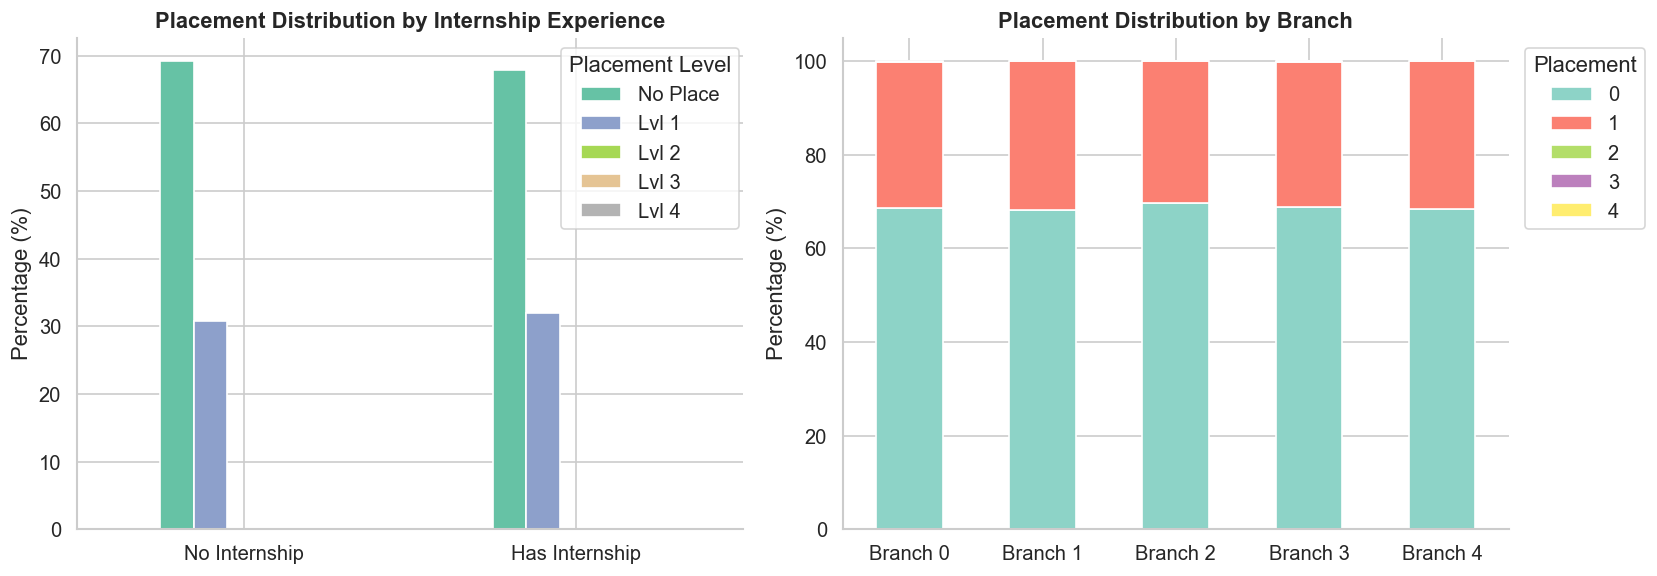

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct = pd.crosstab(df['Internship_Experience'], df['Placement_Label'],
                 normalize='index') * 100
ct.index = ['No Internship', 'Has Internship']
ct[order].plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Placement Distribution by Internship Experience', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Placement Level', bbox_to_anchor=(1.01, 1))

ct2 = pd.crosstab(df['branch_encoded'], df['Placement'])
ct2.index = [f'Branch {i}' for i in ct2.index]
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100
ct2_pct.plot(kind='bar', stacked=True, ax=axes[1],
             colormap='Set3', edgecolor='white')
axes[1].set_title('Placement Distribution by Branch', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Placement', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

### 5.3 Pairplot of Key Features

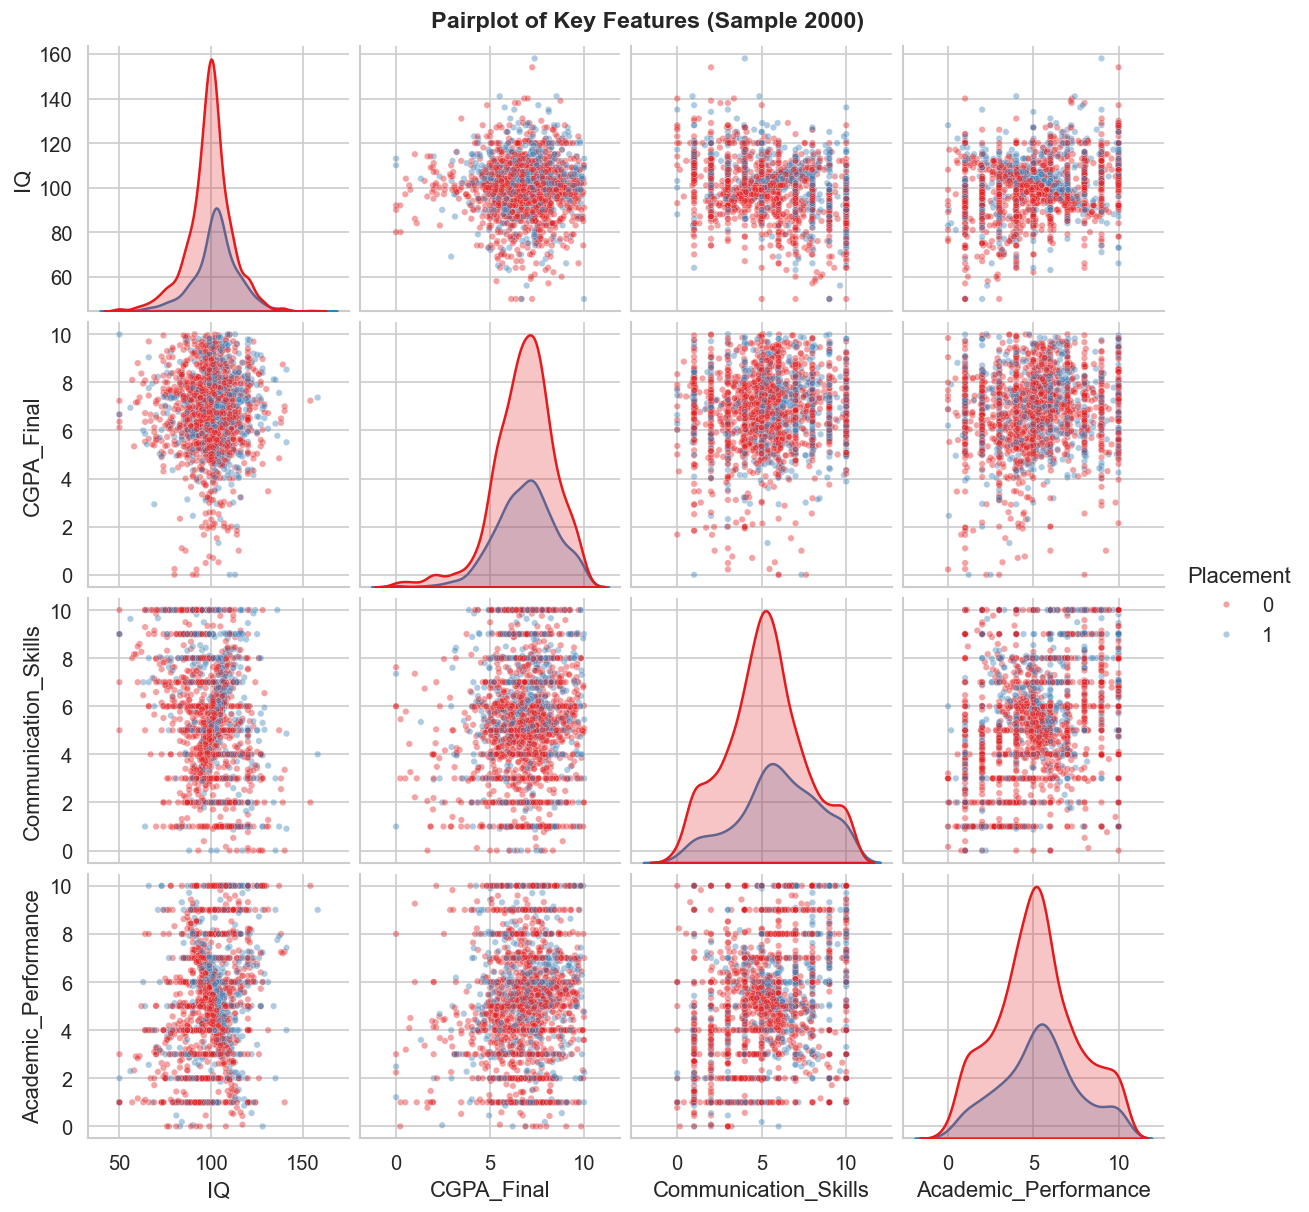

In [10]:
key_features = ['IQ', 'CGPA_Final', 'Communication_Skills', 'Academic_Performance', 'Placement']
sample = df[key_features].sample(2000, random_state=SEED)

g = sns.pairplot(sample, hue='Placement', palette='Set1', diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kws={'linewidth': 1.5})
g.fig.suptitle('Pairplot of Key Features (Sample 2000)', y=1.01, fontsize=14, fontweight='bold')
plt.show()

---
## 6. Correlation Analysis <a id='6'></a>

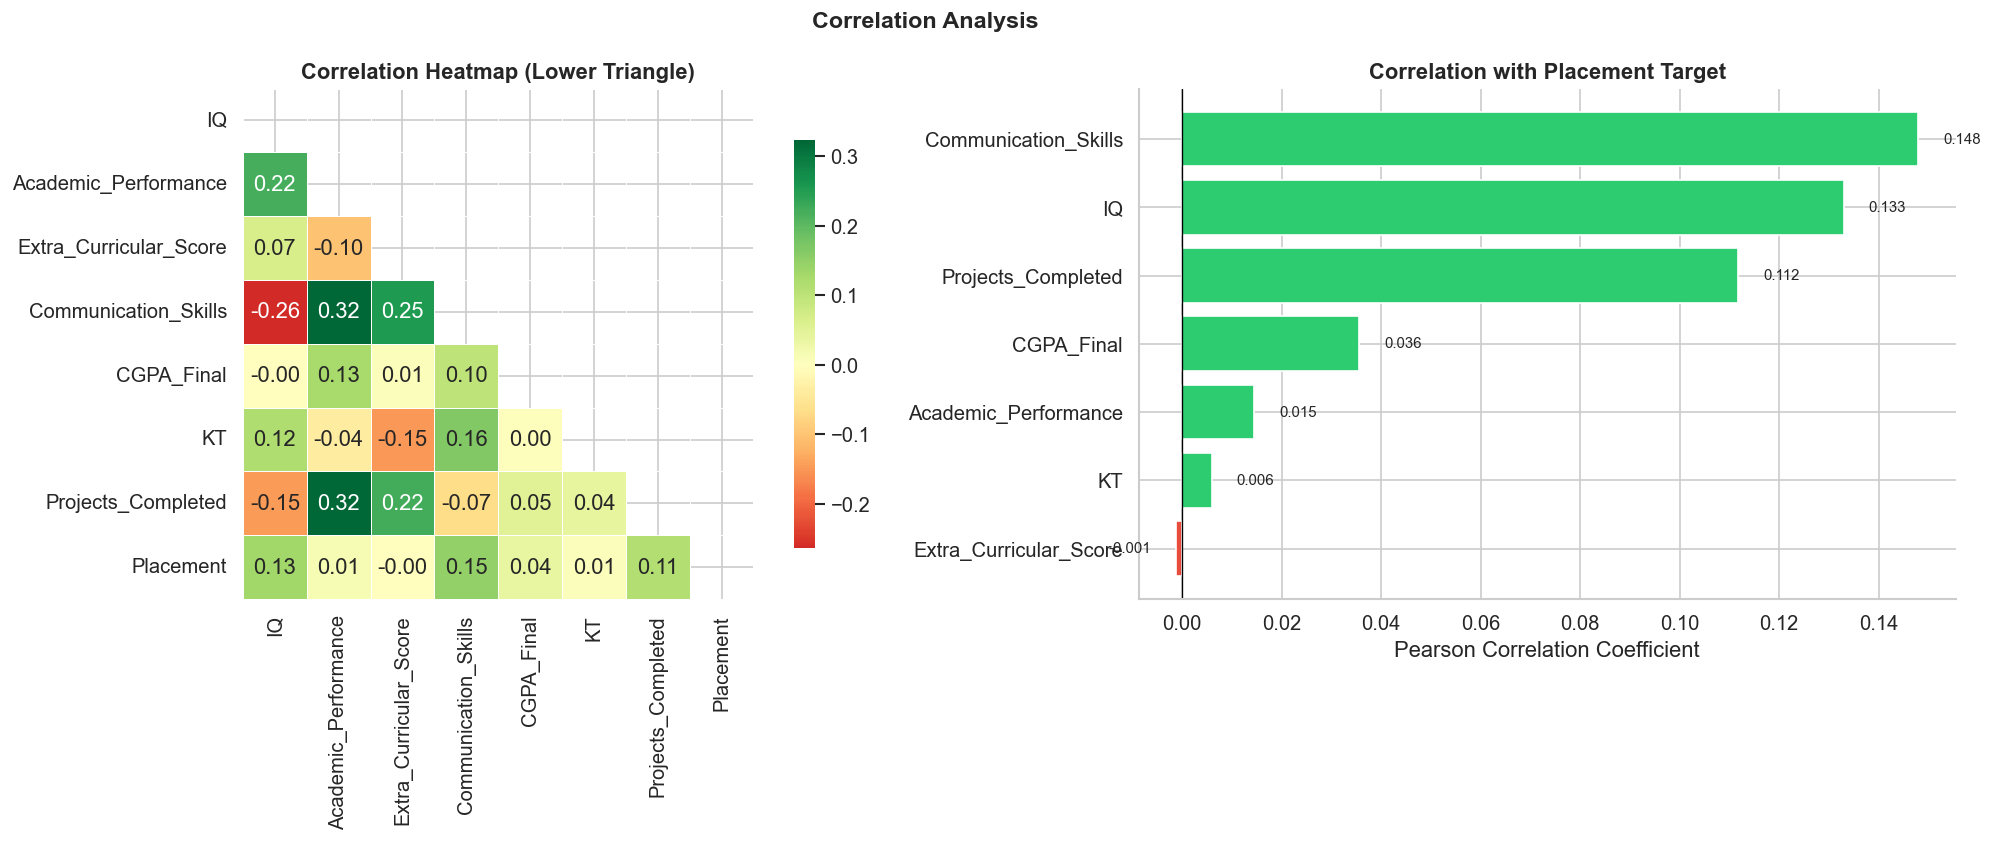

In [11]:
corr = df[continuous_cols + ['Placement']].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Heatmap (Lower Triangle)', fontweight='bold')

placement_corr = corr['Placement'].drop('Placement').sort_values()
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in placement_corr.values]
bars = axes[1].barh(placement_corr.index, placement_corr.values, color=colors_bar,
                    edgecolor='white', linewidth=1)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Placement Target', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')
for bar, val in zip(bars, placement_corr.values):
    x = bar.get_width()
    axes[1].text(x + 0.005 if x >= 0 else x - 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if x >= 0 else 'right', fontsize=9)

plt.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Target Variable Analysis <a id='7'></a>

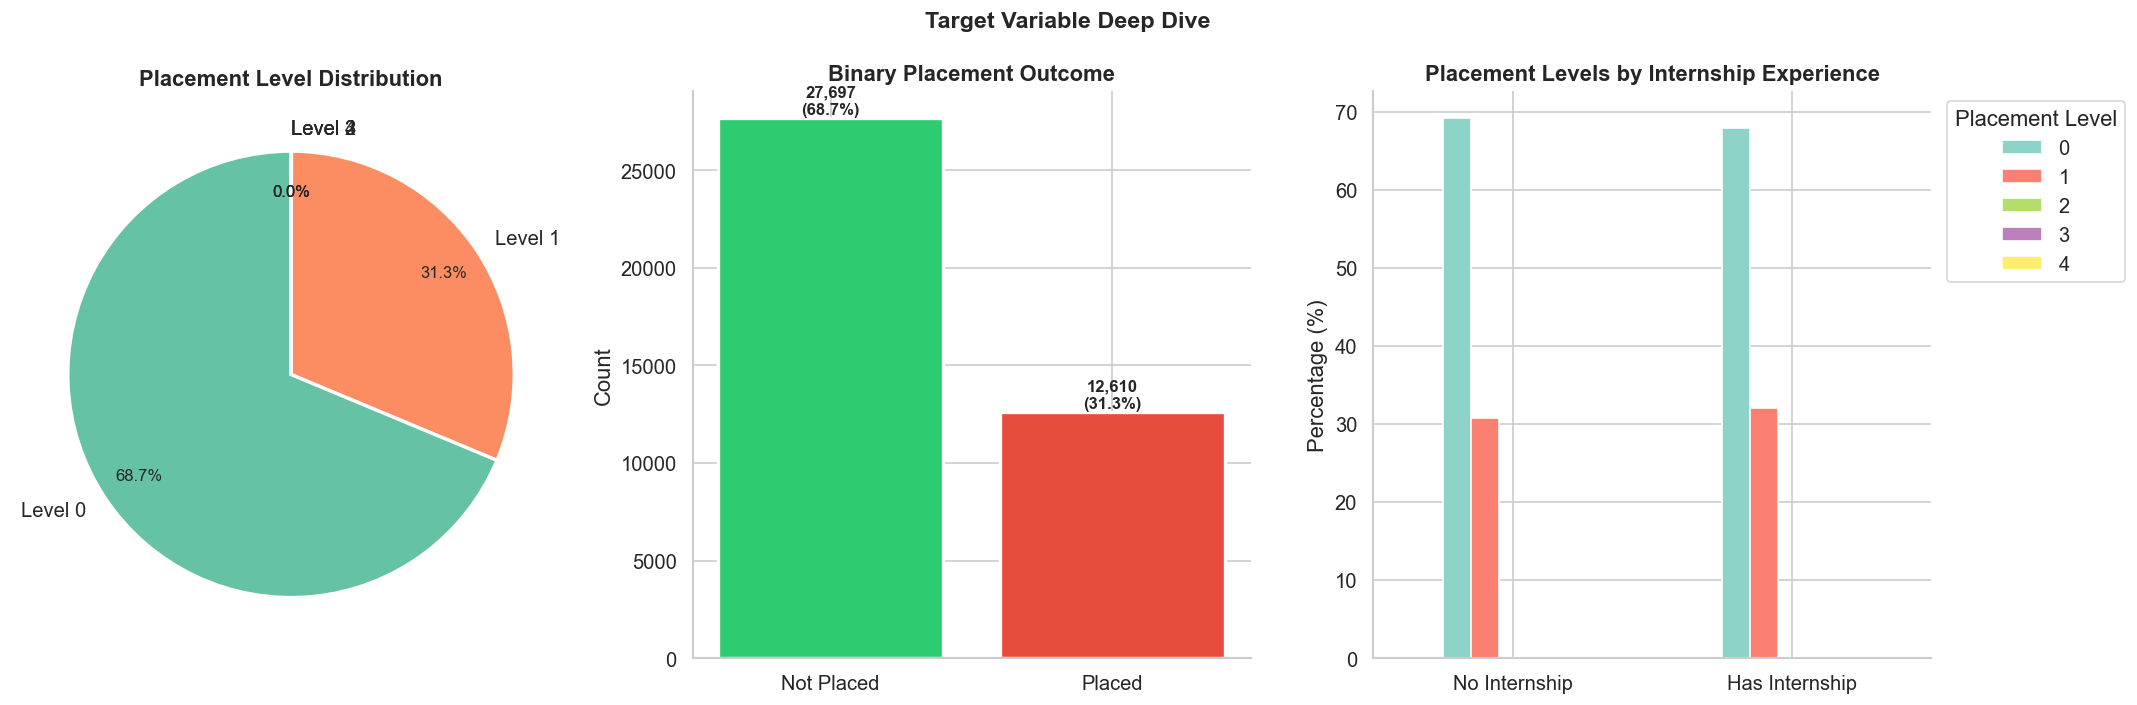

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

placement_counts = df['Placement'].value_counts().sort_index()
palette_pie = sns.color_palette('Set2', len(placement_counts))
wedges, texts, autotexts = axes[0].pie(
    placement_counts.values,
    labels=[f'Level {i}' for i in placement_counts.index],
    autopct='%1.1f%%',
    colors=palette_pie,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.82
)
for autotext in autotexts:
    autotext.set_fontsize(10)
axes[0].set_title('Placement Level Distribution', fontweight='bold')

binary_counts = df['Placement'].apply(lambda x: 'Placed' if x > 0 else 'Not Placed').value_counts()
axes[1].bar(binary_counts.index, binary_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)
axes[1].set_title('Binary Placement Outcome', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(binary_counts.values):
    axes[1].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

internship_placement = df.groupby('Internship_Experience')['Placement'].value_counts(normalize=True).unstack() * 100
internship_placement.index = ['No Internship', 'Has Internship']
internship_placement.plot(kind='bar', ax=axes[2], colormap='Set3',
                          edgecolor='white', linewidth=1)
axes[2].set_title('Placement Levels by Internship Experience', fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Placement Level', bbox_to_anchor=(1.01, 1))

plt.suptitle('Target Variable Deep Dive', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Feature Engineering <a id='8'></a>

We engineer new features that capture meaningful combinations and interactions between existing attributes.

In [13]:
df_fe = df.drop(columns=['Placement_Label']).copy()

df_fe['Academic_IQ_Ratio'] = df_fe['Academic_Performance'] / (df_fe['IQ'] + 1)

df_fe['Overall_Score'] = (
    df_fe['IQ'] * 0.20 +
    df_fe['CGPA_Final'] * 10 * 0.25 +
    df_fe['Academic_Performance'] * 10 * 0.15 +
    df_fe['Communication_Skills'] * 10 * 0.15 +
    df_fe['Extra_Curricular_Score'] * 10 * 0.10 +
    df_fe['Projects_Completed'] * 5 * 0.10 +
    df_fe['Internship_Experience'] * 10 * 0.05
)

df_fe['KT_Penalty'] = np.where(df_fe['KT'] == 0, 1.0,
                       np.where(df_fe['KT'] <= 3, 0.75,
                       np.where(df_fe['KT'] <= 6, 0.50, 0.25)))

df_fe['Practical_Strength'] = (
    df_fe['Projects_Completed'] * 0.5 +
    df_fe['Internship_Experience'] * 3
)

df_fe['Soft_Skill_Index'] = (
    df_fe['Communication_Skills'] * 0.6 +
    df_fe['Extra_Curricular_Score'] * 0.4
)

df_fe['CGPA_Category'] = pd.cut(df_fe['CGPA_Final'],
    bins=[0, 5.0, 6.5, 8.0, 10.1],
    labels=['Low (<5)', 'Average (5-6.5)', 'Good (6.5-8)', 'Excellent (>8)'],
    right=False)

df_fe['IQ_Category'] = pd.cut(df_fe['IQ'],
    bins=[0, 90, 100, 115, 201],
    labels=['Below Avg', 'Average', 'Above Avg', 'Superior'],
    right=False)

df_fe['Clean_Academic'] = (df_fe['KT'] == 0).astype(int)

df_fe['High_Performer'] = (
    (df_fe['CGPA_Final'] >= 7.5) &
    (df_fe['IQ'] >= 105) &
    (df_fe['Communication_Skills'] >= 0.6)
).astype(int)

new_features = ['Academic_IQ_Ratio', 'Overall_Score', 'KT_Penalty',
                'Practical_Strength', 'Soft_Skill_Index', 'Clean_Academic', 'High_Performer']


print(f"Original features: {df.shape[1]-1} | New features: {len(new_features)} | Total: {df_fe.shape[1]-1}")
df_fe[new_features + ['Placement']].head()

Original features: 10 | New features: 7 | Total: 18


,Academic_IQ_Ratio,Overall_Score,KT_Penalty,Practical_Strength,Soft_Skill_Index,Clean_Academic,High_Performer,Placement
0,0.057564,60.271917,0.75,4.0,5.367026,0,0,1
1,0.030686,41.812970,0.75,1.5,2.637419,0,0,1
2,0.025424,61.487500,0.50,3.0,6.600000,0,0,1
3,0.039062,60.136220,0.75,4.0,3.434488,0,0,0
4,0.077670,56.827989,0.75,4.0,3.601196,0,0,0


### 8.1 Engineered Features vs Placement

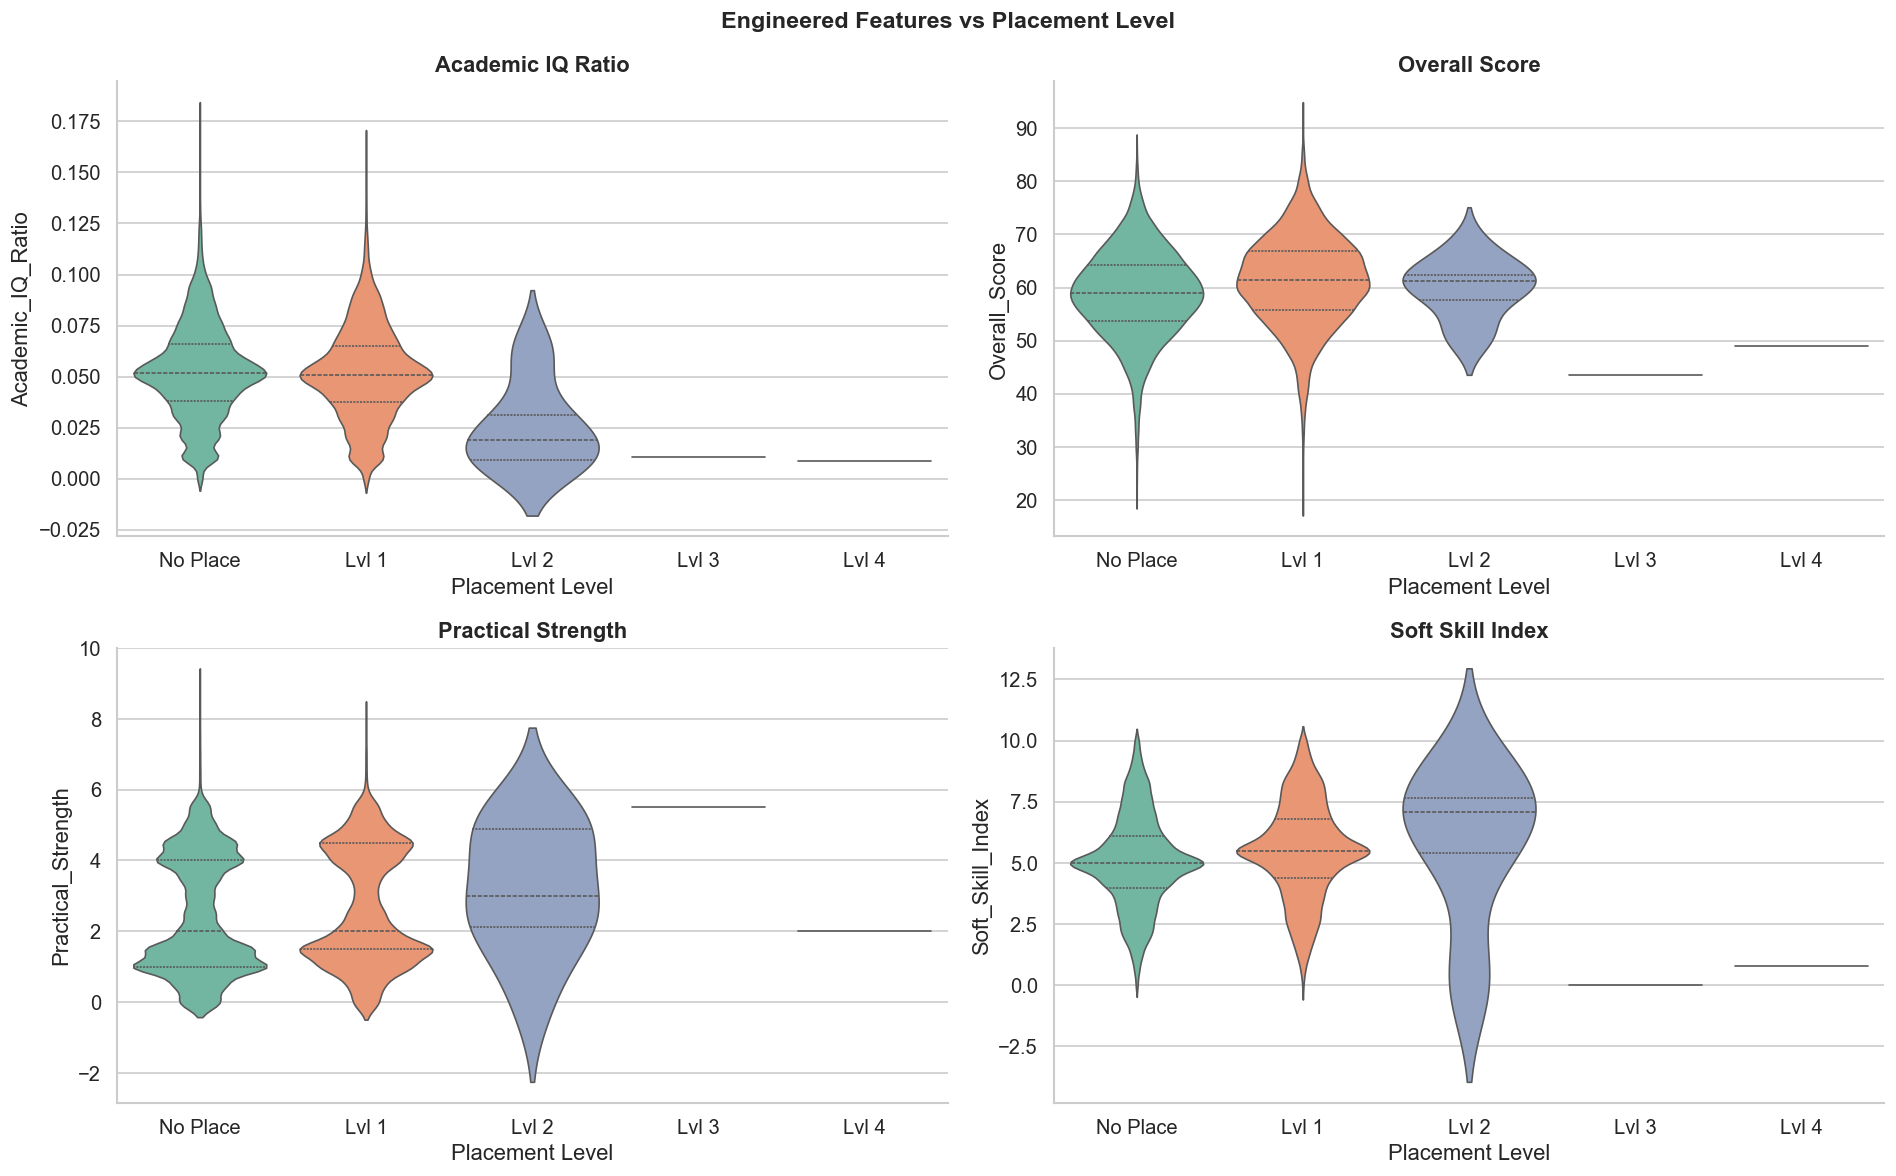

In [14]:
numeric_new = ['Academic_IQ_Ratio', 'Overall_Score', 'Practical_Strength', 'Soft_Skill_Index']
df_fe['Placement_Label'] = df_fe['Placement'].map(placement_labels)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_new):
    sns.violinplot(data=df_fe, x='Placement_Label', y=col, order=order,
                   ax=axes[i], palette='Set2', inner='quartile', linewidth=1)
    axes[i].set_title(col.replace('_', ' '), fontweight='bold')
    axes[i].set_xlabel('Placement Level')

plt.suptitle('Engineered Features vs Placement Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 CGPA Category & IQ Category Analysis

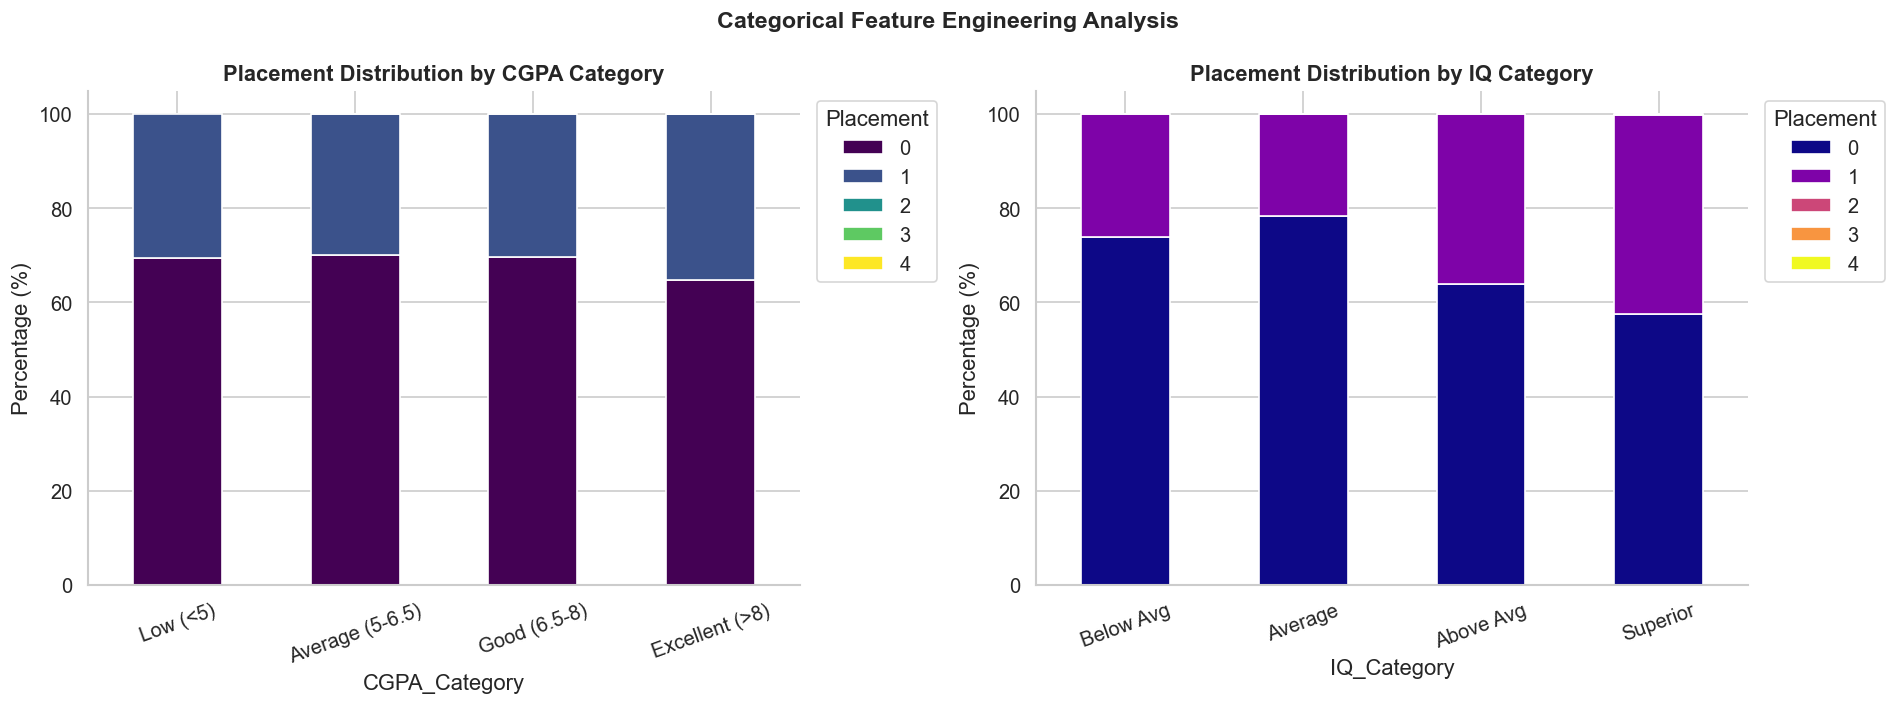

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cgpa_placement = pd.crosstab(df_fe['CGPA_Category'], df_fe['Placement'],
                              normalize='index') * 100
cgpa_placement.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis',
                    edgecolor='white')
axes[0].set_title('Placement Distribution by CGPA Category', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Placement', bbox_to_anchor=(1.01, 1))

iq_placement = pd.crosstab(df_fe['IQ_Category'], df_fe['Placement'],
                            normalize='index') * 100
iq_placement.plot(kind='bar', stacked=True, ax=axes[1], colormap='plasma',
                  edgecolor='white')
axes[1].set_title('Placement Distribution by IQ Category', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Placement', bbox_to_anchor=(1.01, 1))

plt.suptitle('Categorical Feature Engineering Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 High Performer Flag Analysis

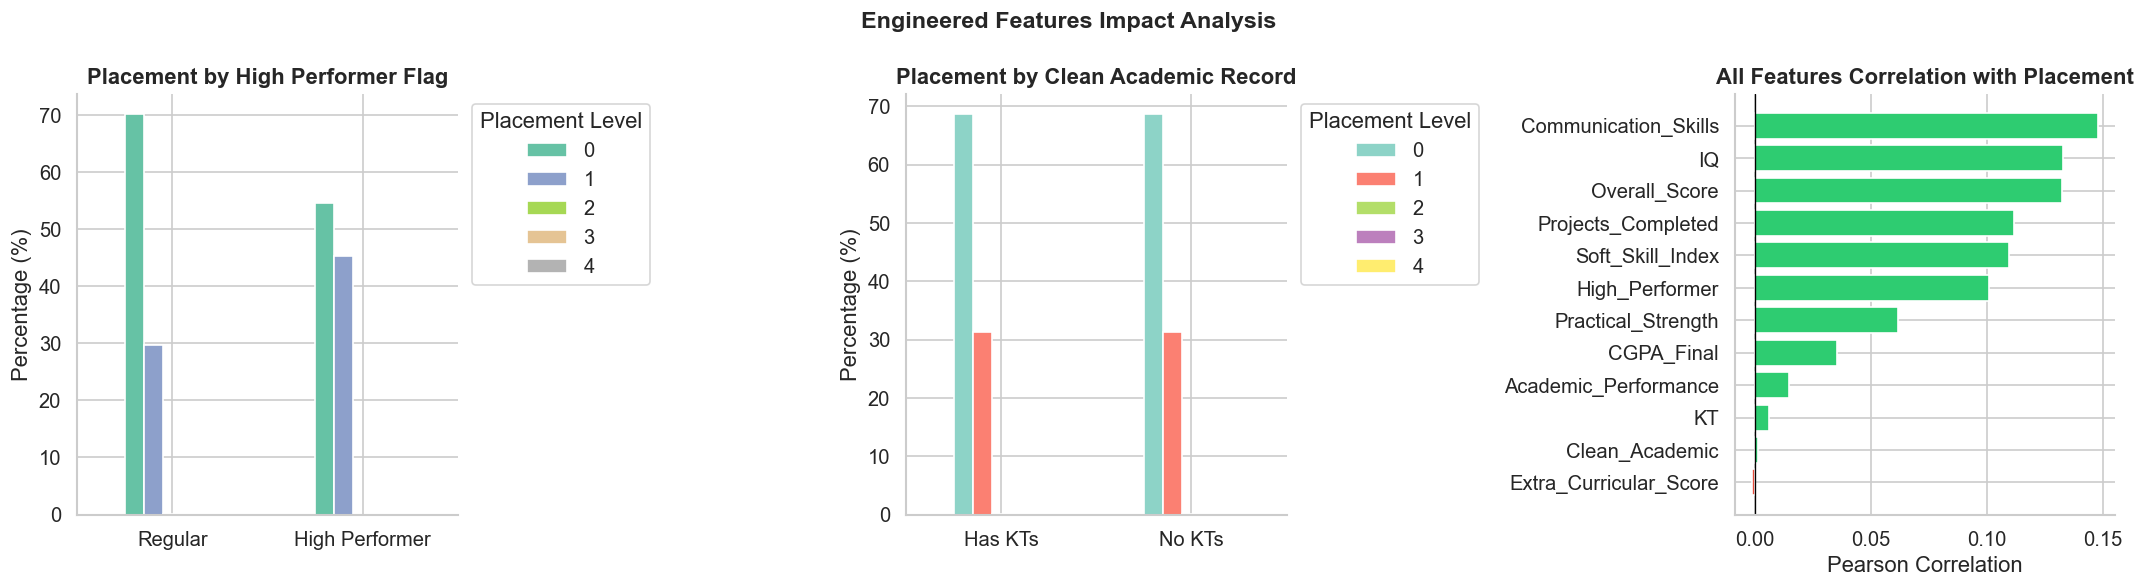

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hp_counts = df_fe.groupby(['High_Performer', 'Placement']).size().unstack(fill_value=0)
hp_pct = hp_counts.div(hp_counts.sum(axis=1), axis=0) * 100
hp_pct.index = ['Regular', 'High Performer']
hp_pct.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Placement by High Performer Flag', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Placement Level', bbox_to_anchor=(1.01, 1))

ca_counts = df_fe.groupby(['Clean_Academic', 'Placement']).size().unstack(fill_value=0)
ca_pct = ca_counts.div(ca_counts.sum(axis=1), axis=0) * 100
ca_pct.index = ['Has KTs', 'No KTs']
ca_pct.plot(kind='bar', ax=axes[1], colormap='Set3', edgecolor='white')
axes[1].set_title('Placement by Clean Academic Record', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Placement Level', bbox_to_anchor=(1.01, 1))

all_features = continuous_cols + ['High_Performer', 'Clean_Academic', 'Practical_Strength', 'Overall_Score', 'Soft_Skill_Index']
corr_with_target = df_fe[all_features + ['Placement']].corr()['Placement'].drop('Placement').sort_values()
colors_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_target.values]
axes[2].barh(corr_with_target.index, corr_with_target.values, color=colors_corr, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('All Features Correlation with Placement', fontweight='bold')
axes[2].set_xlabel('Pearson Correlation')

plt.suptitle('Engineered Features Impact Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Outlier Detection <a id='9'></a>

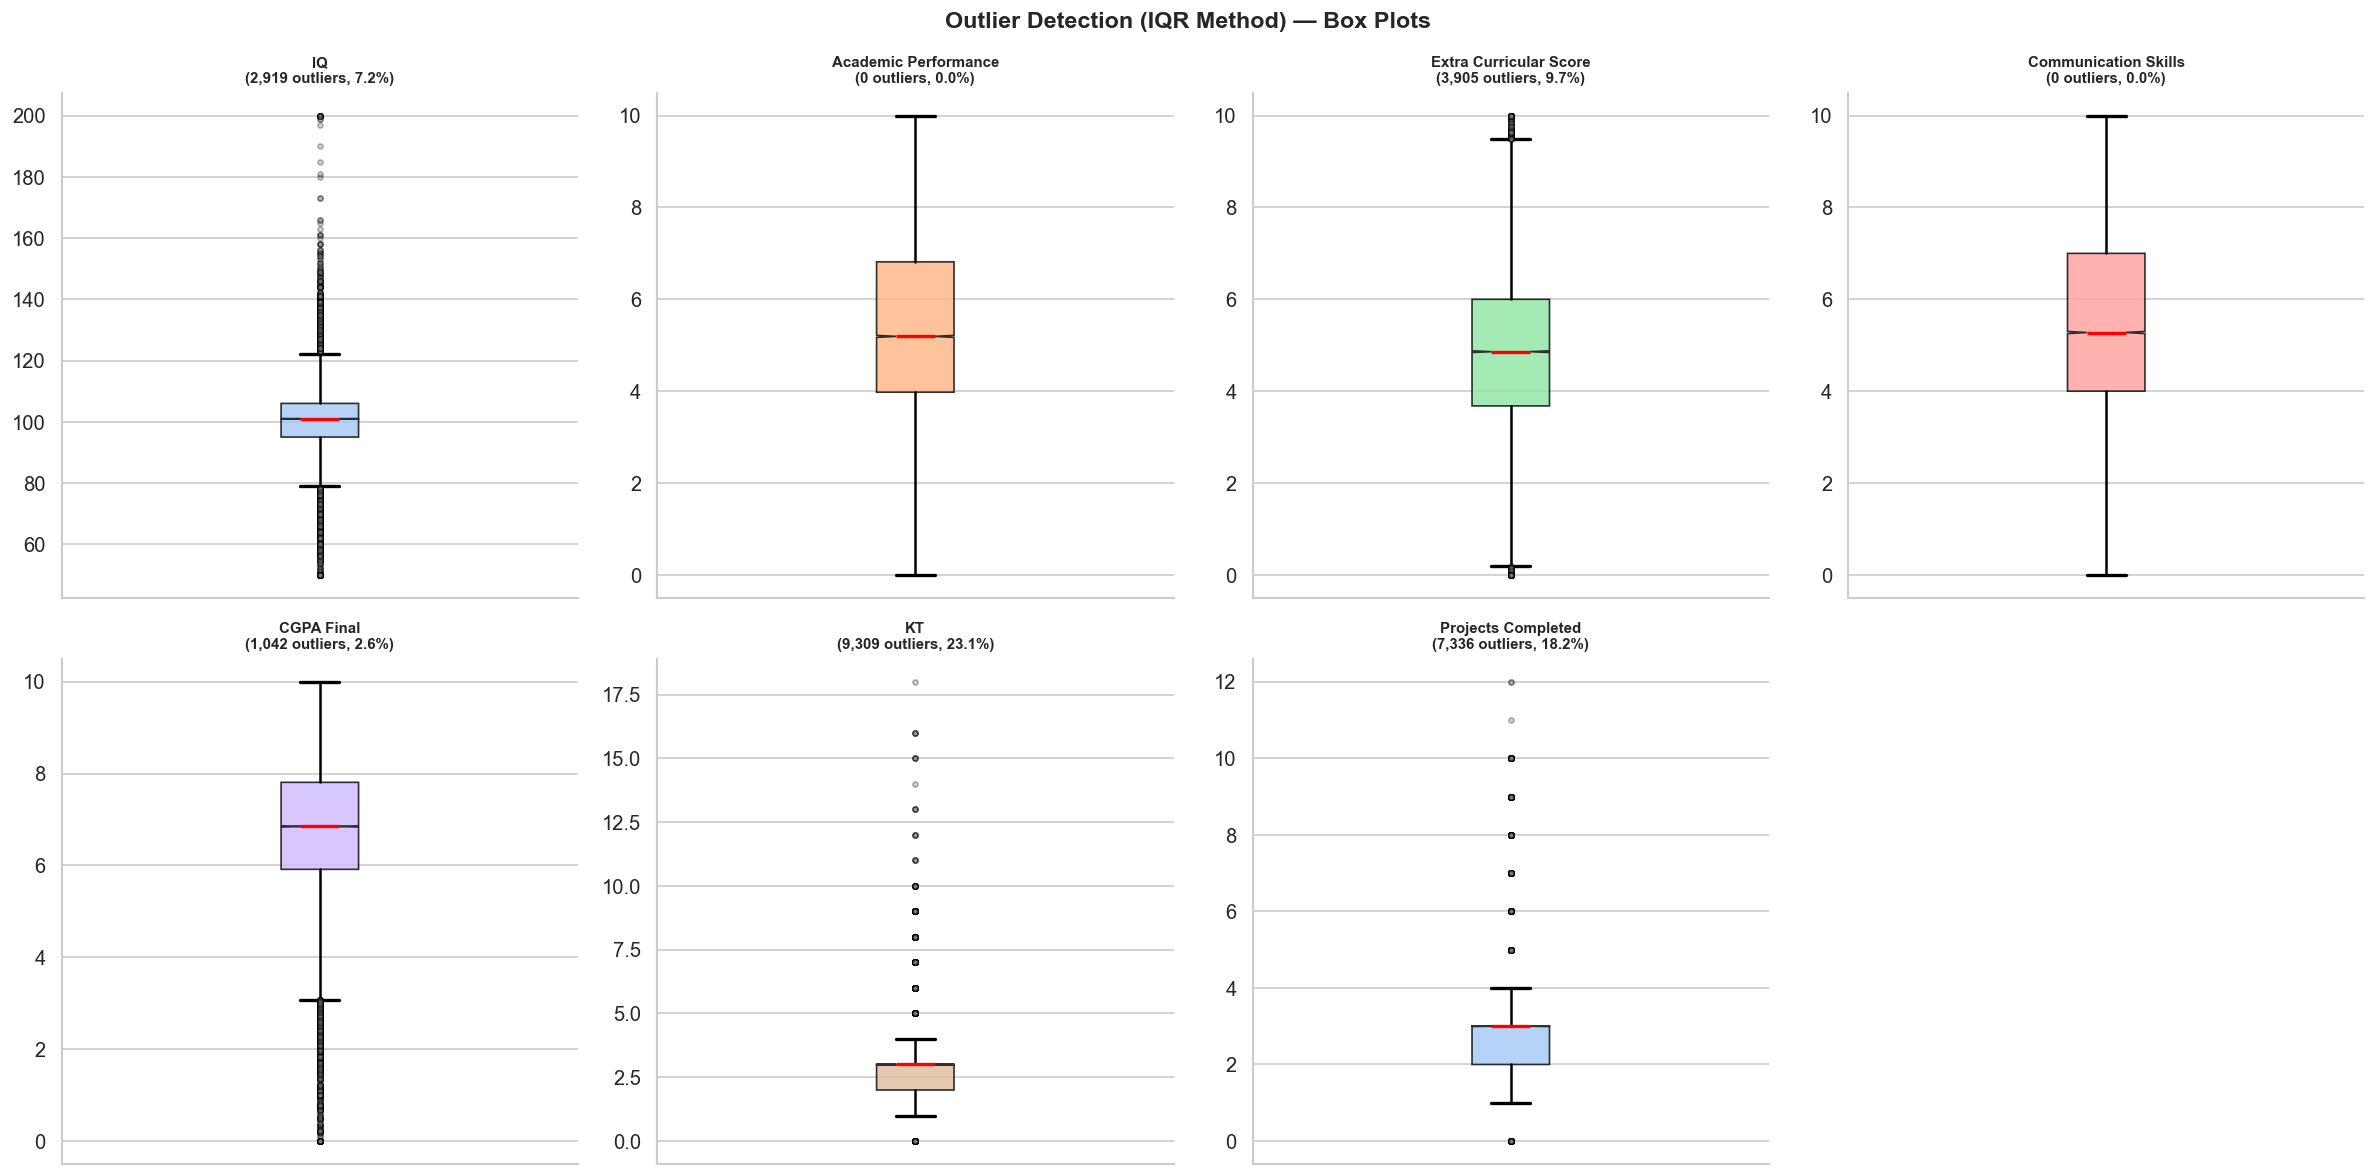

,Outlier Count,Outlier %
IQ,2919.000000,7.24%
Academic_Performance,0.000000,0.00%
Extra_Curricular_Score,3905.000000,9.69%
Communication_Skills,0.000000,0.00%
CGPA_Final,1042.000000,2.59%
KT,9309.000000,23.10%
Projects_Completed,7336.000000,18.20%


In [17]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

outlier_summary = {}

for i, col in enumerate(continuous_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {'count': outliers, 'pct': outliers/len(df)*100}

    bp = axes[i].boxplot(df[col], patch_artist=True, notch=True,
                         boxprops={'facecolor': sns.color_palette('pastel')[i % 6], 'alpha': 0.8},
                         medianprops={'color': 'red', 'linewidth': 2},
                         whiskerprops={'linewidth': 1.5},
                         capprops={'linewidth': 2},
                         flierprops={'marker': 'o', 'markerfacecolor': 'gray',
                                     'markersize': 3, 'alpha': 0.3})
    axes[i].set_title(f"{col.replace('_', ' ')}\n({outliers:,} outliers, {outliers/len(df)*100:.1f}%)",
                      fontweight='bold', fontsize=9)
    axes[i].set_xticks([])

axes[-1].set_visible(False)

plt.suptitle('Outlier Detection (IQR Method) — Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pd.DataFrame(outlier_summary).T.rename(columns={'count': 'Outlier Count', 'pct': 'Outlier %'}).style.format({'Outlier %': '{:.2f}%'}).background_gradient(cmap='Reds', subset=['Outlier %'])

### 9.1 PCA — Dimensionality Reduction for Visualization

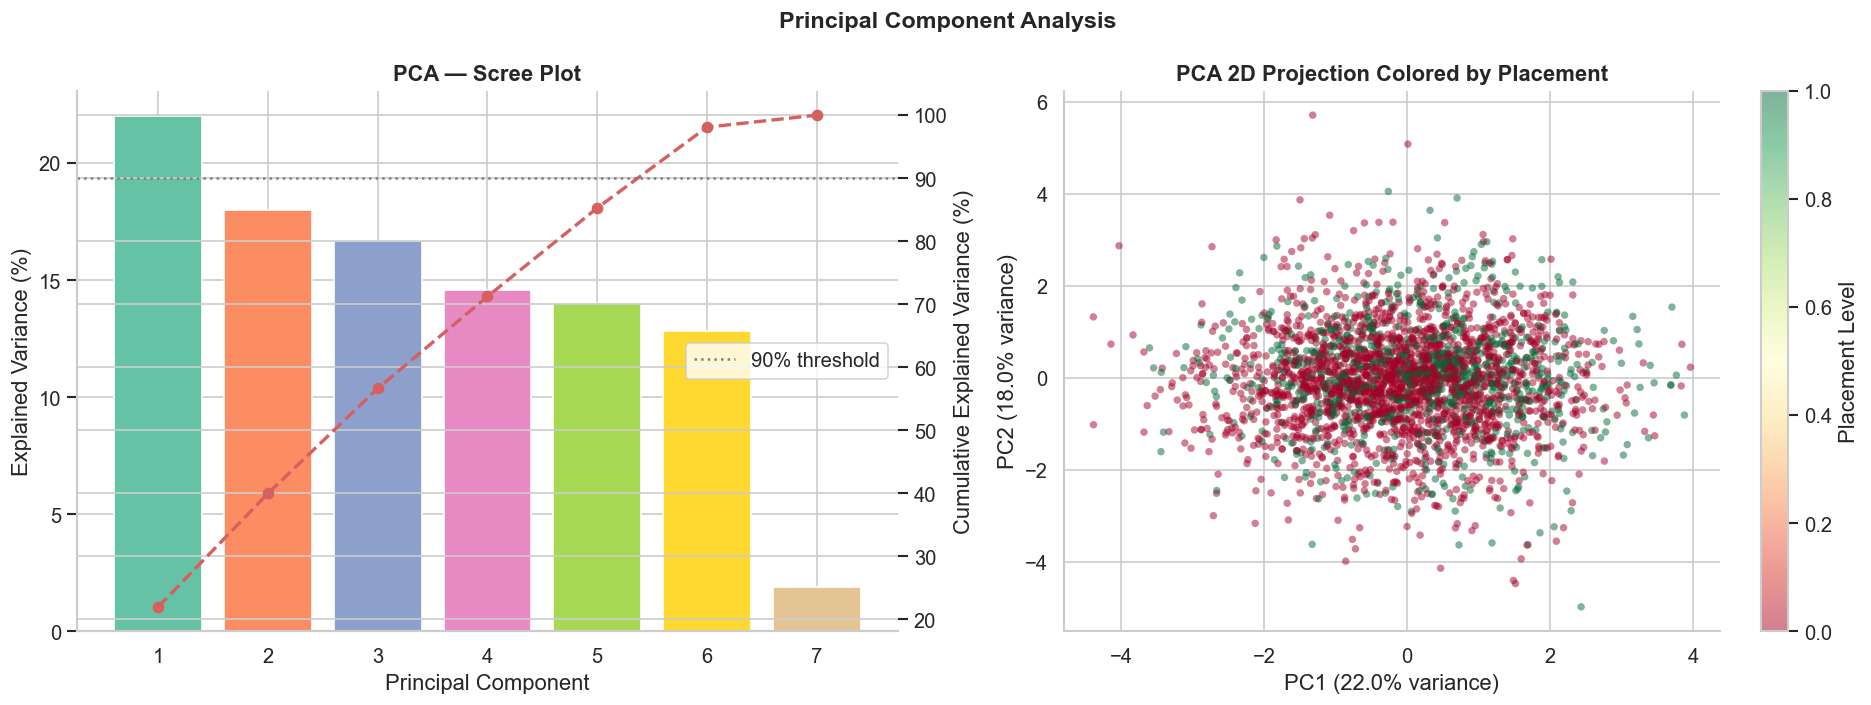

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[continuous_cols])

pca_full = PCA()
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_2d = PCA(n_components=2, random_state=SEED)
X_pca = pca_2d.fit_transform(X_scaled)

sample_idx = np.random.choice(len(df), 3000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(range(1, len(explained)+1), explained * 100,
            color=sns.color_palette('Set2', len(explained)), edgecolor='white')
ax2 = axes[0].twinx()
ax2.plot(range(1, len(cumulative)+1), cumulative * 100,
         'r--o', linewidth=2, markersize=6)
ax2.axhline(90, color='gray', linestyle=':', linewidth=1.5, label='90% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
ax2.set_ylabel('Cumulative Explained Variance (%)')
axes[0].set_title('PCA — Scree Plot', fontweight='bold')
ax2.legend(loc='center right')

scatter = axes[1].scatter(
    X_pca[sample_idx, 0], X_pca[sample_idx, 1],
    c=df['Placement'].values[sample_idx],
    cmap='RdYlGn', alpha=0.5, s=20, edgecolors='none'
)
plt.colorbar(scatter, ax=axes[1], label='Placement Level')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[1].set_title('PCA 2D Projection Colored by Placement', fontweight='bold')

plt.suptitle('Principal Component Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Summary & Key Insights <a id='10'></a>

In [19]:
print("="*60)
print("       EDA SUMMARY — PLACEMENT DATASET")
print("="*60)
print(f"\n Dataset: {df.shape[0]:,} students × {df.shape[1]} features")
print(f" Missing Values: None | Duplicates: {df.duplicated().sum()}")
print(f"\n Target Distribution:")
for k, v in df['Placement'].value_counts().sort_index().items():
    print(f"   Level {k}: {v:,} ({v/len(df)*100:.1f}%)")
print(f"\n   Placed (any level): {(df['Placement'] > 0).sum():,} ({(df['Placement'] > 0).mean()*100:.1f}%)")
print(f"   Not Placed: {(df['Placement'] == 0).sum():,} ({(df['Placement'] == 0).mean()*100:.1f}%)")
print(f"\n Top Correlations with Placement:")
top_corr = df[continuous_cols + ['Placement']].corr()['Placement'].drop('Placement').abs().sort_values(ascending=False)
for feat, val in top_corr.items():
    print(f"   {feat}: {val:.3f}")
print(f"\n🔧 Feature Engineering — Added Features:")
for f in new_features:
    print(f"   + {f}")
print(f"\n PCA: First 2 components explain {(explained[0]+explained[1])*100:.1f}% variance")
print("\n" + "="*60)

       EDA SUMMARY — PLACEMENT DATASET

 Dataset: 40,307 students × 11 features
 Missing Values: None | Duplicates: 3390

 Target Distribution:
   Level 0: 27,697 (68.7%)
   Level 1: 12,598 (31.3%)
   Level 2: 10 (0.0%)
   Level 3: 1 (0.0%)
   Level 4: 1 (0.0%)

   Placed (any level): 12,610 (31.3%)
   Not Placed: 27,697 (68.7%)

 Top Correlations with Placement:
   Communication_Skills: 0.148
   IQ: 0.133
   Projects_Completed: 0.112
   CGPA_Final: 0.036
   Academic_Performance: 0.015
   KT: 0.006
   Extra_Curricular_Score: 0.001

🔧 Feature Engineering — Added Features:
   + Academic_IQ_Ratio
   + Overall_Score
   + KT_Penalty
   + Practical_Strength
   + Soft_Skill_Index
   + Clean_Academic
   + High_Performer

 PCA: First 2 components explain 40.0% variance



---
### 🔑 Key Insights

| # | Insight |
|---|--------|
| 1 | **Class Imbalance**: ~68.7% of students are unplaced (Level 0). Models will need class balancing. |
| 2 | **CGPA & IQ** are the strongest individual predictors of placement level. |
| 3 | **Internship Experience** significantly boosts higher-level placements (Levels 3–4). |
| 4 | **KT (backlogs)** shows a clear negative relationship — zero backlogs strongly correlates with placement. |
| 5 | **Communication Skills** and **Academic Performance** rank mid-tier in predictive power. |
| 6 | **Overall Score** (composite) has higher correlation with Placement than any individual raw feature. |
| 7 | **High Performer** students (CGPA ≥ 7.5 + IQ ≥ 105 + Communication ≥ 0.6) show disproportionately high Level 3–4 placements. |
| 8 | **PCA** shows mild cluster separation across placement levels — tree-based models should perform well. |